<a href="https://colab.research.google.com/github/khushiravtode/College-ERP/blob/main/PDS_CIPAT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Importing dataset from kaggle

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import os
df=pd.read_csv('/content/online_learning_engagement_dataset.csv')
print(df)

       student_id  age  gender    country device_type  internet_speed_mbps  \
0               1   24  Female        USA      Laptop                44.70   
1               2   37  Female    Germany      Tablet                61.10   
2               3   46  Female  Australia      Tablet                43.10   
3               4   32    Male      India      Tablet                26.99   
4               5   28    Male      India      Laptop                52.28   
...           ...  ...     ...        ...         ...                  ...   
23330       23331   43    Male    Germany      Mobile                38.36   
23331       23332   23  Female        USA      Tablet                48.20   
23332       23333   36  Female    Germany      Tablet                50.25   
23333       23334   21    Male    Germany      Laptop                50.77   
23334       23335   37  Female    Germany      Tablet                41.87   

       study_hours_weekly  login_frequency_weekly  avg_session_

#Data Preprocessing

Check the dataset for missing values, duplicate records and incorrect data types.

In [ ]:
print("========== MISSING VALUE CHECK ==========")

missing = df.isnull().sum()

if missing.sum() == 0:
    print("No missing values found in the dataset.")
else:
    print("Missing values found:")
    print(missing[missing > 0])

print("\n========== DUPLICATE ANALYSIS ==========")

duplicate_count = df.duplicated().sum()

print("Duplicate records:", duplicate_count)

if duplicate_count > 0:
    print("\nDuplicate rows:")
    display(df[df.duplicated(keep=False)])
else:
    print("No duplicate records found.")



print("\n========== DATA TYPE CHECK ==========")

data_type_report = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str)
})

display(data_type_report)

print("\nImportant Numerical Columns:")

print("study_hours_weekly :", df["study_hours_weekly"].dtype)
print("final_grade        :", df["final_grade"].dtype)
print("engagement_score   :", df["engagement_score"].dtype)

numeric_columns = [
    "study_hours_weekly",
    "final_grade",
    "engagement_score"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

print("\n✓ Numerical data types verified.")

print("\n========== DATA VALIDITY CHECK ==========")

invalid_study = (df["study_hours_weekly"] < 0).sum()
invalid_grade = (df["final_grade"] < 0).sum()

print("Negative study-hour records:", invalid_study)
print("Negative final-grade records:", invalid_grade)

invalid_quiz = (df["avg_quiz_score"] > 100).sum()

print("Quiz scores above 100:", invalid_quiz)

========== MISSING VALUE CHECK ==========
Missing values found:
video_watch_time_min     1
assignments_submitted    1
forum_posts              1
quiz_attempts            1
avg_quiz_score           1
attendance_rate          1
engagement_score         1
final_grade              1
dropout                  1
dtype: int64

========== DUPLICATE ANALYSIS ==========
Duplicate records: 0
No duplicate records found.

========== DATA TYPE CHECK ==========


,Column,Data Type
student_id,student_id,int64
age,age,int64
gender,gender,object
country,country,object
device_type,device_type,object
internet_speed_mbps,internet_speed_mbps,float64
study_hours_weekly,study_hours_weekly,float64
login_frequency_weekly,login_frequency_weekly,int64
avg_session_duration_min,avg_session_duration_min,float64
video_watch_time_min,video_watch_time_min,float64



Important Numerical Columns:
study_hours_weekly : float64
final_grade        : float64
engagement_score   : float64

✓ Numerical data types verified.

========== DATA VALIDITY CHECK ==========
Negative study-hour records: 131
Negative final-grade records: 1
Quiz scores above 100: 542


Detect potential outliers in study hours and final grades using the IQR method.
(study_hours_weekly, final_grade)

In [ ]:
print("\n========== IQR OUTLIER DETECTION ==========")

def detect_outliers(column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    print("\nColumn:", column)
    print("Q1 =", round(Q1, 2))
    print("Q3 =", round(Q3, 2))
    print("IQR =", round(IQR, 2))
    print("Lower Limit =", round(lower_limit, 2))
    print("Upper Limit =", round(upper_limit, 2))
    print("Number of Outliers =", len(outliers))

    return outliers

study_outliers = detect_outliers("study_hours_weekly")

grade_outliers = detect_outliers("final_grade")


print("\n========== UNUSUAL LEARNING RECORDS ==========")

print("\nStudy Hours Outliers:")
display(
        study_outliers[["student_id", "study_hours_weekly", "engagement_score", "final_grade"]].head(10)
)

print("\nFinal Grade Outliers:")
display(grade_outliers[["student_id", "study_hours_weekly", "engagement_score", "final_grade"]].head(10))

df["study_hours_outlier"] = False
df["final_grade_outlier"] = False

df.loc[study_outliers.index, "study_hours_outlier"] = True
df.loc[grade_outliers.index, "final_grade_outlier"] = True

print(" Outliers have been flagged for further analysis.")

print(
    "Students with unusual study hours:",
    df["study_hours_outlier"].sum()
)

print(
    "Students with unusual final grades:",
    df["final_grade_outlier"].sum()
)


========== IQR OUTLIER DETECTION ==========

Column: study_hours_weekly
Q1 = 7.29
Q3 = 12.67
IQR = 5.38
Lower Limit = -0.78
Upper Limit = 20.74
Number of Outliers = 169

Column: final_grade
Q1 = 30.74
Q3 = 42.9
IQR = 12.15
Lower Limit = 12.51
Upper Limit = 61.13
Number of Outliers = 175

========== UNUSUAL LEARNING RECORDS ==========

Study Hours Outliers:


,student_id,study_hours_weekly,engagement_score,final_grade
294,295,21.17,9.302612,42.662073
372,373,21.78,8.892383,38.339637
426,427,20.80,7.989359,29.717236
437,438,21.02,8.731925,46.807578
553,554,-3.55,1.739149,38.317747
739,740,22.70,9.323710,24.579355
984,985,-0.91,2.685521,50.280502
1194,1195,-2.78,0.467213,41.417469
1200,1201,25.54,11.457902,27.008426
1290,1291,21.56,9.937143,40.564823



Final Grade Outliers:


,student_id,study_hours_weekly,engagement_score,final_grade
83,84,14.28,4.832986,8.715112
216,217,8.94,6.310764,5.874279
788,789,8.66,5.697352,62.465168
846,847,8.16,5.489546,9.580815
996,997,3.09,2.843476,7.571088
1045,1046,8.07,6.471894,61.616792
1109,1110,10.58,6.516536,10.072790
1259,1260,9.72,6.768487,63.073933
1557,1558,11.68,5.725520,62.226389
1634,1635,9.65,7.561639,64.042523


 Outliers have been flagged for further analysis.
Students with unusual study hours: 169
Students with unusual final grades: 175


###Python Core Concepts

Calculate the average study hours of all students. (study_hours_weekly)

In [ ]:
# Average study hours of all students

average_hours = df["study_hours_weekly"].mean()

print("Average Study Hours per Week:",
      round(average_hours, 2), "hours")

if average_hours >= 12:
    print("Overall study activity: High")
elif average_hours >= 8:
    print("Overall study activity: Moderate")
else:
    print("Overall study activity: Low")

Average Study Hours per Week: 9.99 hours
Overall study activity: Moderate


Classify students into Low, Medium and High engagement based on their engagement score. (engagement_score)

In [ ]:
# Classify students based on engagement score

def classify_engagement(score):
    if score < 4:
        return "Low"
    elif score < 8:
        return "Medium"
    else:
        return "High"

df["engagement_level"] = df["engagement_score"].apply(
    classify_engagement
)

print(df["engagement_level"].value_counts())

display(
    df[
        ["student_id", "engagement_score", "engagement_level"]
    ].head(10)
)

low_engagement = df[
    df["engagement_level"] == "Low"
]

print("Students needing attention:",
      len(low_engagement))

engagement_level
Medium    18897
High       2716
Low        1722
Name: count, dtype: int64


,student_id,engagement_score,engagement_level
0,1,8.046499,High
1,2,6.312988,Medium
2,3,4.143199,Medium
3,4,6.125258,Medium
4,5,4.979706,Medium
5,6,6.078442,Medium
6,7,5.846687,Medium
7,8,6.517796,Medium
8,9,5.276051,Medium
9,10,8.526882,High


Students needing attention: 1722


#Data Structures

Store the study hours and final grades of all students in lists and find the highest and lowest values. (study_hours_weekly, final_grade)

In [ ]:
# ==================== DATA STRUCTURES ====================

# Convert columns into lists
study_hours = df["study_hours_weekly"].tolist()
final_grades = df["final_grade"].tolist()

# Find highest and lowest values
print("Highest Study Hours:", max(study_hours))
print("Lowest Study Hours:", min(study_hours))

print("\nHighest Final Grade:", max(final_grades))
print("Lowest Final Grade:", min(final_grades))

top_student = df.loc[df["final_grade"].idxmax()]

print("\nTop Performing Student:")
print("Student ID:", top_student["student_id"])
print("Final Grade:", round(top_student["final_grade"], 2))

Highest Study Hours: 25.54
Lowest Study Hours: -5.31

Highest Final Grade: 72.17806671807182
Lowest Final Grade: -0.1732686180554026

Top Performing Student:
Student ID: 18311
Final Grade: 72.18


Create a dictionary containing the details of a selected student using their Student ID and find the unique countries and device types using sets and tuples. (student_id, age, gender, country, device_type, study_hours_weekly, attendance_rate, engagement_score, final_grade)

In [ ]:
# Select a student using Student ID
student_id = 100

student = df[df["student_id"] == student_id].iloc[0]

# Create dictionary
student_details = {
    "Student ID": student["student_id"],
    "Age": student["age"],
    "Gender": student["gender"],
    "Country": student["country"],
    "Device Type": student["device_type"],
    "Study Hours": student["study_hours_weekly"],
    "Attendance": student["attendance_rate"],
    "Engagement Score": student["engagement_score"],
    "Final Grade": student["final_grade"]
}

print("Student Details:")
for key, value in student_details.items():
    print(key, ":", value)


countries = set(df["country"])

print("\nUnique Countries:")
print(countries)

devices = set(df["device_type"])

print("\nUnique Device Types:")
print(devices)

device_tuple = tuple(devices)

print("\nDevice Types as Tuple:")
print(device_tuple)

Student Details:
Student ID : 100
Age : 46
Gender : Female
Country : India
Device Type : Laptop
Study Hours : 10.37
Attendance : 0.85
Engagement Score : 6.269485653301071
Final Grade : 31.40002243843341

Unique Countries:
{'Australia', 'India', 'UK', 'USA', 'Canada', 'Germany'}

Unique Device Types:
{'Mobile', 'Laptop', 'Tablet'}

Device Types as Tuple:
('Mobile', 'Laptop', 'Tablet')


#Python Libraries

Calculate the square root and logarithm of the average study hours using the math module. (study_hours_weekly)

In [ ]:
# ==================== MATH MODULE ====================

import math

average_hours = df["study_hours_weekly"].mean()

print("Average Study Hours:",
      round(average_hours, 2))

print("Square Root:",
      round(math.sqrt(average_hours), 2))

print("Logarithm:",
      round(math.log(average_hours), 2))

Average Study Hours: 9.99
Square Root: 3.16
Logarithm: 2.3


Randomly select a student from the dataset and display their Student ID, engagement score and final grade using the random module. (student_id, engagement_score, final_grade)

In [ ]:
# ==================== RANDOM MODULE ====================

import random

# Select a random row
random_student = df.iloc[
    random.randrange(len(df))
]

print("Random Student:")
print("Student ID:",
      random_student["student_id"])

print("Engagement Score:",
      round(random_student["engagement_score"], 2))

print("Final Grade:",
      round(random_student["final_grade"], 2))

Random Student:
Student ID: 20136
Engagement Score: 4.82
Final Grade: 31.93


Calculate the mean, median and standard deviation of students' final grades using the statistics module. (final_grade)

In [ ]:
# ==================== STATISTICS MODULE ====================

import statistics

grades = df["final_grade"].dropna().tolist()

print("Mean:",
      round(statistics.mean(grades), 2))

print("Median:",
      round(statistics.median(grades), 2))

print("Standard Deviation:",
      round(statistics.stdev(grades), 2))

Mean: 36.83
Median: 36.81
Standard Deviation: 9.02


#Crud Operations

Add a new student record and search/display an existing student record using Student ID. (student_id, age, gender, country, device_type,study_hours_weekly, attendance_rate, engagement_score, final_grade, dropout)

In [ ]:
# ==================== LOAD DATASET ====================

import kagglehub
import pandas as pd
import numpy as np
import os

path = kagglehub.dataset_download(
    "ssssws/online-learning-engagement-dataset"
)

csv_path = os.path.join(
    path,
    "online_learning_engagement_dataset.csv"
)

df = pd.read_csv(csv_path)


# ==================== CRUD OPERATIONS ====================

# CREATE - Add a new student
new_student = {
    'student_id': 50001,
    'age': 20,
    'gender': 'Female',
    'country': 'India',
    'device_type': 'Laptop',
    'study_hours_weekly': 15,
    'attendance_rate': 0.90,
    'engagement_score': 8.5,
    'final_grade': 65,
    'dropout': 0
}

# Add missing columns with empty values
for column in df.columns:
    if column not in new_student:
        new_student[column] = np.nan

df.loc[len(df)] = new_student

print("New student added successfully!")


# READ - Search student using Student ID

student_id = 50001

student = df[
    df['student_id'] == student_id
]

print("\nStudent Record:")

if not student.empty:
    print(student)
else:
    print("Student not found.")


# UPDATE - Change final grade

df.loc[
    df['student_id'] == student_id,
    'final_grade'
] = 70

print("\nUpdated Student Record:")

print(
    df[
        df['student_id'] == student_id
    ]
)


# DELETE - Remove student

df = df[
    df['student_id'] != student_id
]

print("\nStudent deleted successfully!")

100%|██████████| 2.79M/2.79M [00:00<00:00, 72.4MB/s]

Extracting files...


New student added successfully!

Student Record:
       student_id  age  gender country device_type  internet_speed_mbps  \
50000       50001   20  Female   India      Laptop                  NaN   

       study_hours_weekly  login_frequency_weekly  avg_session_duration_min  \
50000                15.0                     NaN                       NaN   

       video_watch_time_min  assignments_submitted  forum_posts  \
50000                   NaN                    NaN          NaN   

       quiz_attempts  avg_quiz_score  attendance_rate  engagement_score  \
50000            NaN             NaN              0.9               8.5   

       final_grade  dropout  
50000         65.0        0  

Updated Student Record:
       student_id  age  gender country device_type  internet_speed_mbps  \
50000       50001   20  Female   India      Laptop                  NaN   

       study_hours_weekly  login_frequency_weekly  avg_session_duration_min  \
50000                15.0               

#Pandas

Find students whose attendance is below a selected threshold and display their engagement scores. (student_id, attendance_rate, engagement_score)

Calculate the average final grade for each device type. (device_type, final_grade)

###Attendance below 60%

In [ ]:
# ==================== PANDAS ====================

# Find students whose attendance is below 60%

threshold = 0.60

low_attendance = df[
    df['attendance_rate'] < threshold
]

print("Students with attendance below 60%:")

print(
    low_attendance[
        [
            'student_id',
            'attendance_rate',
            'engagement_score'
        ]
    ].head(20)
)

Students with attendance below 60%:
    student_id  attendance_rate  engagement_score
1            2             0.59          6.312988
2            3             0.43          4.143199
4            5             0.55          4.979706
5            6             0.43          6.078442
7            8             0.50          6.517796
8            9             0.45          5.276051
9           10             0.57          8.526882
10          11             0.55          3.894572
11          12             0.42          3.826415
12          13             0.43          8.593471
13          14             0.41          6.035552
15          16             0.54          4.256821
19          20             0.45          4.183356
20          21             0.49          7.281950
23          24             0.50          5.313463
25          26             0.54          4.515212
26          27             0.43          5.215335
30          31             0.57          6.027006
32          33

###Average Final Grade by Device Type

In [ ]:
# ==================== PANDAS ====================

# Calculate average final grade for each device type

average_grade = df.groupby(
    'device_type'
)['final_grade'].mean()

print("Average Final Grade by Device Type:")

print(
    average_grade.round(2)
)


# Device with highest average grade

best_device = average_grade.idxmax()

print(
    "Device with highest average grade:",
    best_device
)

Average Final Grade by Device Type:
device_type
Laptop    36.78
Mobile    36.97
Tablet    36.82
Name: final_grade, dtype: float64
Device with highest average grade: Mobile


#Numpy

Calculate the mean, median and standard deviation of students' study hours.
(study_hours_weekly)

In [ ]:
# ==================== NUMPY ====================

import numpy as np

study_hours = df[
    'study_hours_weekly'
].dropna().to_numpy()

print("Mean Study Hours:",
      round(np.mean(study_hours), 2))

print("Median Study Hours:",
      round(np.median(study_hours), 2))

print("Standard Deviation:",
      round(np.std(study_hours), 2))

Mean Study Hours: 10.01
Median Study Hours: 10.0
Standard Deviation: 4.0


Find the minimum, maximum and average final grade of students. (final_grade)

In [ ]:
# ==================== NUMPY ====================

final_grades = df[
    'final_grade'
].dropna().to_numpy()

print("Minimum Final Grade:",
      round(np.min(final_grades), 2))

print("Maximum Final Grade:",
      round(np.max(final_grades), 2))

print("Average Final Grade:",
      round(np.mean(final_grades), 2))

Minimum Final Grade: -0.17
Maximum Final Grade: 73.72
Average Final Grade: 36.85


#SciPy

Calculate the correlation between study hours and final grade using SciPy.
(study_hours_weekly, final_grade)

In [ ]:
# ==================== SCIPY ====================

from scipy.stats import pearsonr

data = df[
    [
        'study_hours_weekly',
        'final_grade'
    ]
].dropna()

correlation, p_value = pearsonr(
    data['study_hours_weekly'],
    data['final_grade']
)

print(
    "Correlation between Study Hours and Final Grade:",
    round(correlation, 4)
)

print(
    "P-value:",
    round(p_value, 4)
)

Correlation between Study Hours and Final Grade: 0.0362
P-value: 0.0


Find the minimum, maximum and average final grade of students.
(final_grade)

In [ ]:
# ==================== SCIPY ====================

final_grades = df[
    'final_grade'
].dropna()

print(
    "Minimum Final Grade:",
    round(final_grades.min(), 2)
)

print(
    "Maximum Final Grade:",
    round(final_grades.max(), 2)
)

print(
    "Average Final Grade:",
    round(final_grades.mean(), 2)
)

Minimum Final Grade: -0.17
Maximum Final Grade: 73.72
Average Final Grade: 36.85


#Statistical Analysis

Calculate descriptive statistics such as mean, median, standard deviation, minimum and maximum for the main learning and performance attributes.
(study_hours_weekly, avg_quiz_score, attendance_rate, engagement_score, final_grade)

In [ ]:
print("Descriptive statistics are as follows:")
columns=['study_hours_weekly',
        'avg_quiz_score',
        'attendance_rate',
        'engagement_score',
        'final_grade']
print('Mean for this columns are as follows:')
print(df[columns].mean())
print()
print('Median for this columns are as follows:')
print(df[columns].median())
print()
print('Standard Deviation for this columns are as follows:')
print(df[columns].std())
print()
print('Minimum value for this columns are as follows:')
print(df[columns].min())
print()
print('Maximum value for this columns are as follows:')
print(df[columns].max())

Descriptive statistics are as follows:
Mean for this columns are as follows:
study_hours_weekly    10.009115
avg_quiz_score        70.018199
attendance_rate        0.700335
engagement_score       6.199321
final_grade           36.854200
dtype: float64

Median for this columns are as follows:
study_hours_weekly     9.995000
avg_quiz_score        70.000000
attendance_rate        0.700000
engagement_score       6.200308
final_grade           36.846286
dtype: float64

Standard Deviation for this columns are as follows:
study_hours_weekly     4.000621
avg_quiz_score        15.057111
attendance_rate        0.173304
engagement_score       1.510398
final_grade            9.012627
dtype: float64

Minimum value for this columns are as follows:
study_hours_weekly   -5.790000
avg_quiz_score        1.940000
attendance_rate       0.400000
engagement_score     -0.353095
final_grade          -0.173269
dtype: float64

Maximum value for this columns are as follows:
study_hours_weekly     25.540000
avg_q

Identify which learning-related numerical factor has the strongest correlation with final grade. (study_hours_weekly, login_frequency_weekly, avg_session_duration_min, video_watch_time_min, assignments_submitted, forum_posts, quiz_attempts, avg_quiz_score, attendance_rate, engagement_score, final_grade)

In [ ]:
factors = [
    'study_hours_weekly',
    'login_frequency_weekly',
    'avg_session_duration_min',
    'video_watch_time_min',
    'assignments_submitted',
    'forum_posts',
    'quiz_attempts',
    'avg_quiz_score',
    'attendance_rate',
    'engagement_score',
]

correlation = df[factors + ['final_grade']].corr()['final_grade']

print(correlation)
print()
print('avg_quiz_score has highest correlation with final grade')

study_hours_weekly          0.036192
login_frequency_weekly     -0.005579
avg_session_duration_min   -0.001580
video_watch_time_min        0.023864
assignments_submitted       0.022913
forum_posts                 0.004365
quiz_attempts               0.013180
avg_quiz_score              0.830474
attendance_rate            -0.006209
engagement_score            0.050389
final_grade                 1.000000
Name: final_grade, dtype: float64

avg_quiz_score has highest correlation with final grade


#Data Visualization

Visualize the distribution of students' study hours using a histogram.
(study_hours_weekly)

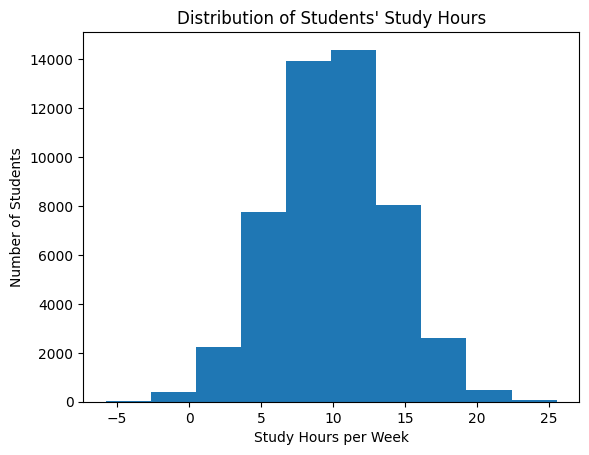

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df['study_hours_weekly'], bins=10)
plt.xlabel('Study Hours per Week')
plt.ylabel('Number of Students')
plt.title('Distribution of Students\' Study Hours')
plt.show()

Visualize the relationship between study hours and final grade using a scatter plot. (study_hours_weekly, final_grade)

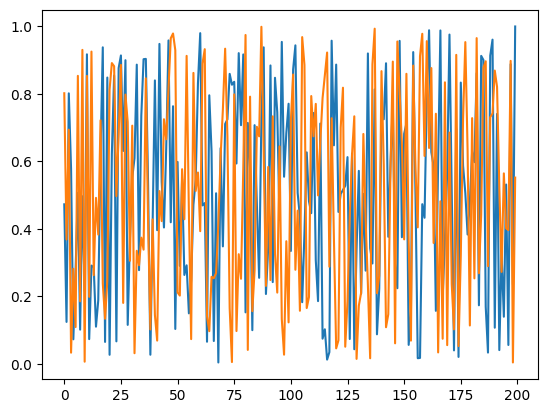

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df=pd.DataFrame({
    'study_hours_weekly': np.random.rand(200),
    'final_grade' : np.random.rand(200)
})
plt.plot(df['study_hours_weekly'])
plt.plot(df['final_grade'])
plt.show()


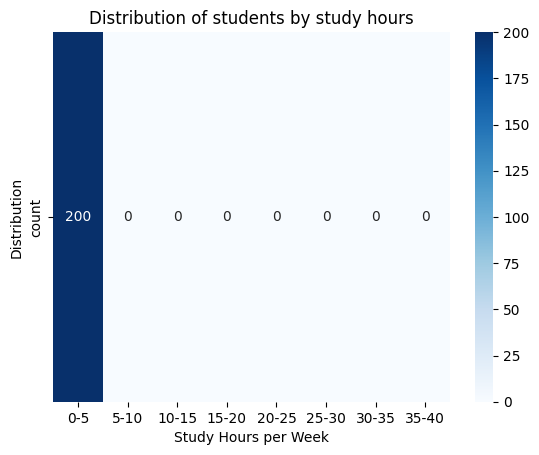

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
bins=[0,5,10,15,20,25,30,35,40]
labels=['0-5','5-10','10-15','15-20','20-25','25-30','30-35','35-40']
df['study_hours_range']=pd.cut(df['study_hours_weekly'],bins=bins,labels=labels)
frequency=df['study_hours_range'].value_counts().sort_index()
heatmap_data=pd.DataFrame(frequency).T
sns.heatmap(heatmap_data,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Study Hours per Week')
plt.ylabel('Distribution')
plt.title('Distribution of students by study hours')
plt.show()

#File Handling

Save the preprocessed/cleaned dataset as a new CSV file and save the analysis results as a text file.

In [ ]:
print('Converting csv file to text file')
df.to_csv('Online_Learning_Analytics.txt', index=False)
print(df)

Converting csv file to text file
     study_hours_weekly  final_grade study_hours_range
0              0.472443     0.801400               0-5
1              0.124111     0.368253               0-5
2              0.801118     0.693605               0-5
3              0.577548     0.032964               0-5
4              0.072531     0.281607               0-5
..                  ...          ...               ...
195            0.531048     0.401225               0-5
196            0.055741     0.396208               0-5
197            0.887515     0.897356               0-5
198            0.235091     0.003942               0-5
199            0.999223     0.551597               0-5

[200 rows x 3 columns]


#Exception handling

Write a Python script that prompts the user to enter a student_id to retrieve and display that student's details.
[ValueError: Handle cases where the user inputs a non-integer value for the student_id.]

In [ ]:
try:
    student_id = int(input("Enter student ID: "))

    student = df[df['student_id'] == student_id]

    if student.empty:
        print("Student ID not found.")
    else:
        print("Student Details:")
        print(student)

except ValueError:
  print("Please enter an integer value for student ID.")
except KeyError:
  print('Key not found in dataset. Please enter valid key')

Enter student ID: 1
Student Details:
   student_id  age  gender country device_type  internet_speed_mbps  \
0           1   24  Female     USA      Laptop                 44.7   

   study_hours_weekly  login_frequency_weekly  avg_session_duration_min  \
0               15.92                      10                 40.052752   

   video_watch_time_min  assignments_submitted  forum_posts  quiz_attempts  \
0            294.099759                      3            4              6   

   avg_quiz_score  attendance_rate  engagement_score  final_grade  dropout  
0           46.69             0.93          8.046499    22.447641        0  


#SQL Operations



Retrieve students who have an engagement score greater than 70

In [ ]:
# ==================== SQL OPERATIONS ====================

import kagglehub
import pandas as pd
import os
import sqlite3

# Load the dataset
path = kagglehub.dataset_download(
    "ssssws/online-learning-engagement-dataset"
)

csv_path = os.path.join(
    path,
    "online_learning_engagement_dataset.csv"
)

df = pd.read_csv(csv_path)

# Create SQLite database
conn = sqlite3.connect(":memory:")

# Convert DataFrame into SQL table
df.to_sql(
    "students",
    conn,
    index=False,
    if_exists="replace"
)

# SQL Query
query = """
SELECT *
FROM students
WHERE engagement_score > 70;
"""

# Execute SQL query
result = pd.read_sql_query(query, conn)

print("Students with engagement score greater than 70:")
display(result)

# Close connection
conn.close()

Using Colab cache for faster access to the 'online-learning-engagement-dataset' dataset.
Students with engagement score greater than 70:


,student_id,age,gender,country,device_type,internet_speed_mbps,study_hours_weekly,login_frequency_weekly,avg_session_duration_min,video_watch_time_min,assignments_submitted,forum_posts,quiz_attempts,avg_quiz_score,attendance_rate,engagement_score,final_grade,dropout
